In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

In [2]:
df = pd.read_csv('F:\Project Raw Data\HR\WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Shape: 1470 rows x 35 columns


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
# Check for missing values and duplicates
missing = df.isnull().sum()
dupes = df.duplicated().sum()

print("Missing values:", missing[missing > 0].to_dict() if missing.sum() > 0 else "None")
print(f"Duplicate rows: {dupes}")

Missing values: None
Duplicate rows: 0


In [5]:
# Quick look at numeric distributions
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.92,9.14,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.49,403.51,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.19,8.11,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.91,1.02,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.00,0.00,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.87,602.02,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.72,1.09,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.89,20.33,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.73,0.71,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.06,1.11,1.0,1.00,2.0,3.00,5.0


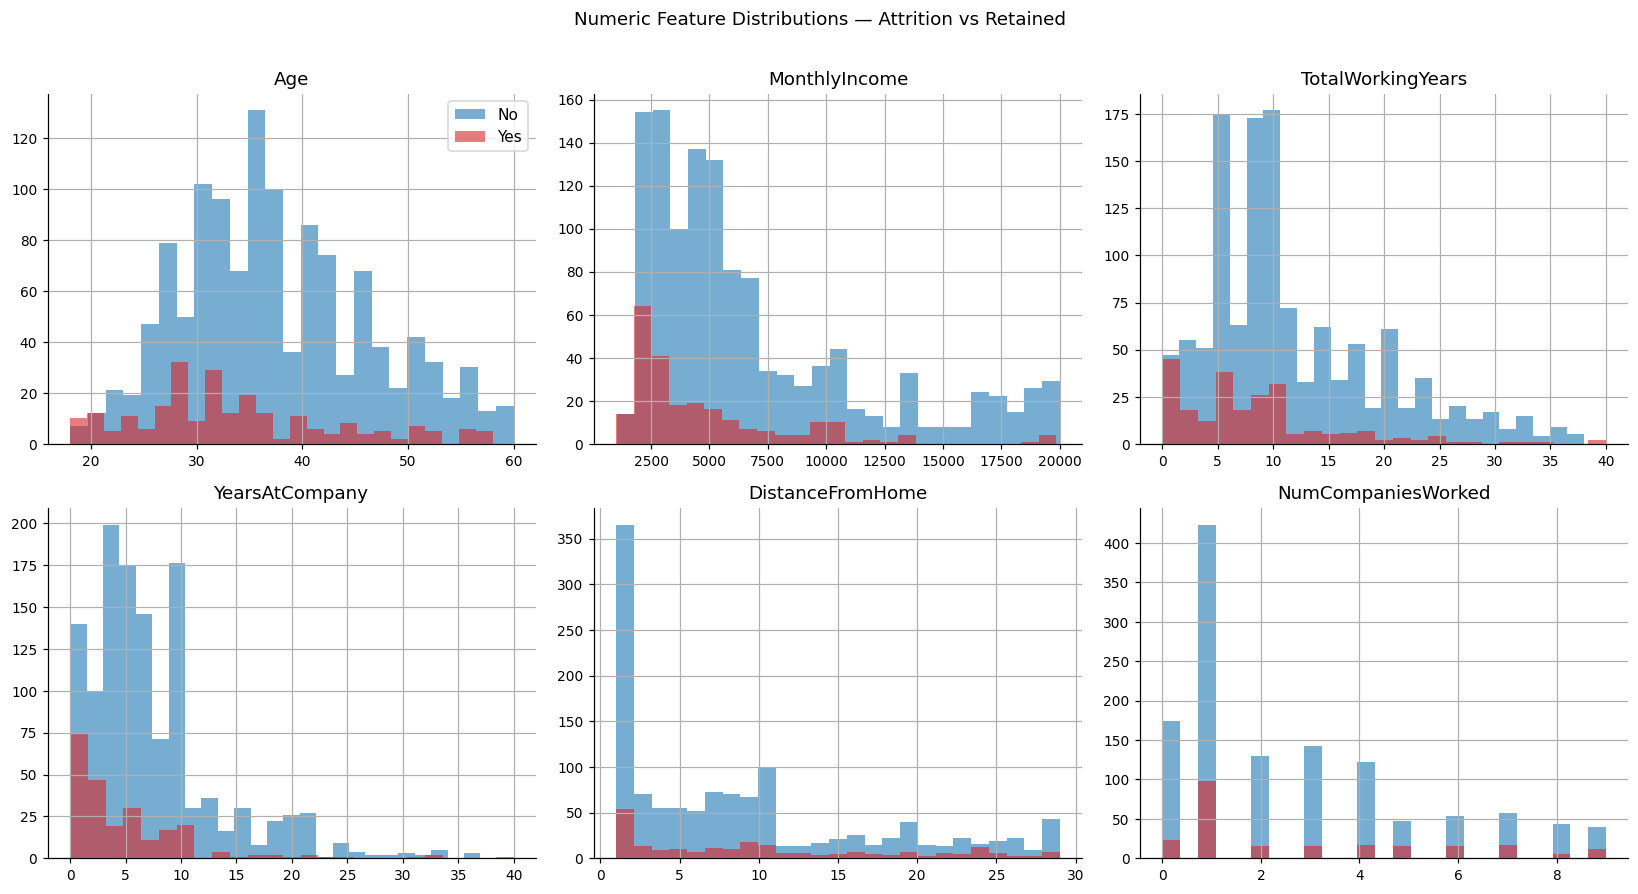

In [6]:
# Distribution of key numeric columns, split by attrition
cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
        'DistanceFromHome', 'NumCompaniesWorked']

colors = {'Yes': '#d62728', 'No': '#1f77b4'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    for label, grp in df.groupby('Attrition'):
        grp[col].hist(bins=25, ax=ax, alpha=0.6, label=label, color=colors[label])
    ax.set_title(col)
    ax.set_xlabel('')
    if i == 0:
        ax.legend()

plt.suptitle('Numeric Feature Distributions — Attrition vs Retained', y=1.01)
plt.tight_layout()
plt.savefig('01_numeric_distributions.png', bbox_inches='tight')
plt.show()

Attrition breakdown:
  Yes: 237 employees (16.12%)
  No: 1233 employees (83.88%)


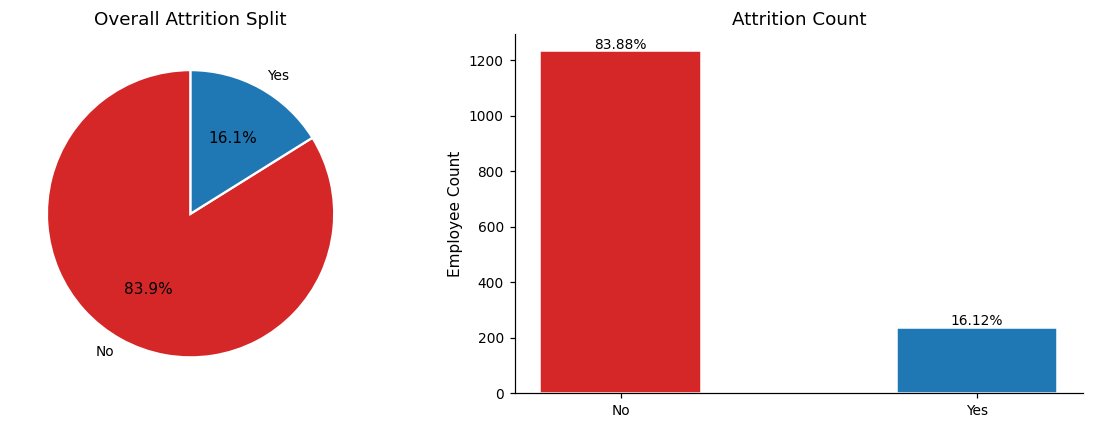

In [7]:
# Overall attrition split
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True).mul(100).round(2)

print("Attrition breakdown:")
for label in ['Yes', 'No']:
    print(f"  {label}: {attrition_counts[label]} employees ({attrition_pct[label]}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# pie
axes[0].pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#d62728', '#1f77b4'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Overall Attrition Split')

# bar
bars = axes[1].bar(attrition_counts.index, attrition_counts.values,
                   color=['#d62728', '#1f77b4'], width=0.45, edgecolor='white')
for bar, pct in zip(bars, attrition_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{pct}%', ha='center', fontsize=9)
axes[1].set_ylabel('Employee Count')
axes[1].set_title('Attrition Count')

plt.tight_layout()
plt.savefig('02_overall_attrition.png', bbox_inches='tight')
plt.show()

Attrition               Attrition_Rate_%
Department                              
Sales                              20.63
Human Resources                    19.05
Research & Development             13.84


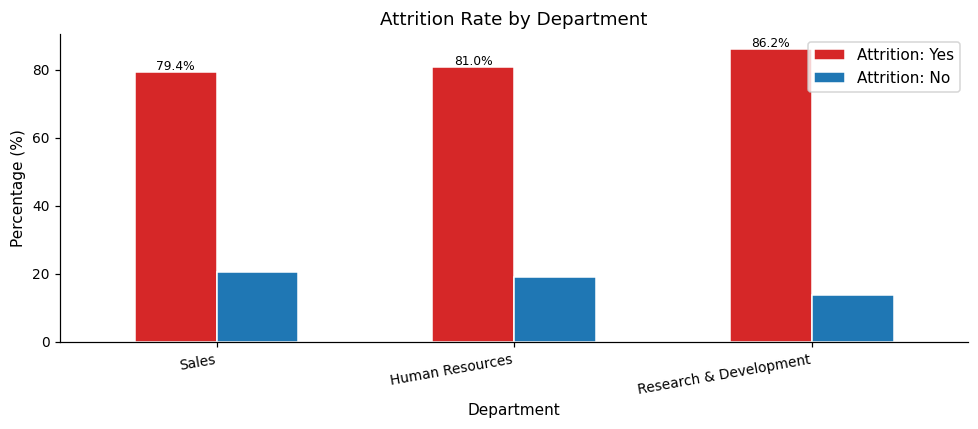

In [8]:
# Attrition rate by department
dept_attr = (df.groupby('Department')['Attrition']
               .value_counts(normalize=True)
               .mul(100)
               .unstack()
               .sort_values('Yes', ascending=False))

print(dept_attr[['Yes']].rename(columns={'Yes': 'Attrition_Rate_%'}).round(2))

fig, ax = plt.subplots(figsize=(9, 4))
dept_attr.plot(kind='bar', ax=ax, color=['#d62728', '#1f77b4'], edgecolor='white', width=0.55)
ax.set_title('Attrition Rate by Department')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(dept_attr.index, rotation=10, ha='right')
ax.legend(['Attrition: Yes', 'Attrition: No'])

# label the Yes bars
for bar in ax.patches[:len(dept_attr)]:
    ax.annotate(f'{bar.get_height():.1f}%',
                (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5),
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('03_attrition_by_department.png', bbox_inches='tight')
plt.show()

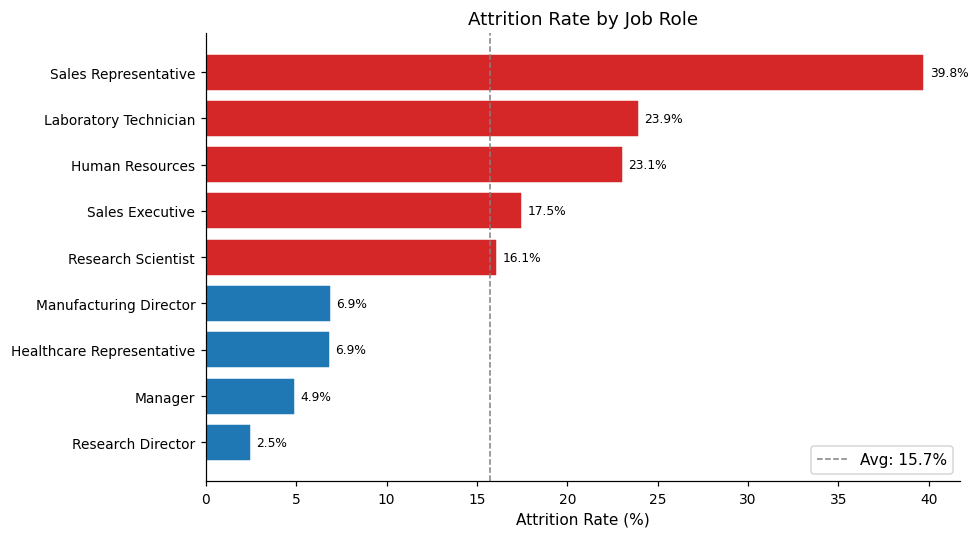

In [9]:
# Attrition rate by job role
role_attr = (df.groupby('JobRole')['Attrition']
               .apply(lambda x: (x == 'Yes').mean() * 100)
               .sort_values(ascending=True))

avg = role_attr.mean()

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#d62728' if v > avg else '#1f77b4' for v in role_attr.values]
ax.barh(role_attr.index, role_attr.values, color=bar_colors, edgecolor='white')
ax.axvline(x=avg, color='gray', linestyle='--', linewidth=1, label=f'Avg: {avg:.1f}%')
for i, v in enumerate(role_attr.values):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)
ax.set_title('Attrition Rate by Job Role')
ax.set_xlabel('Attrition Rate (%)')
ax.legend()

plt.tight_layout()
plt.savefig('04_attrition_by_jobrole.png', bbox_inches='tight')
plt.show()

Attrition rate by overtime status:
Attrition     No    Yes
OverTime               
No         89.56  10.44
Yes        69.47  30.53


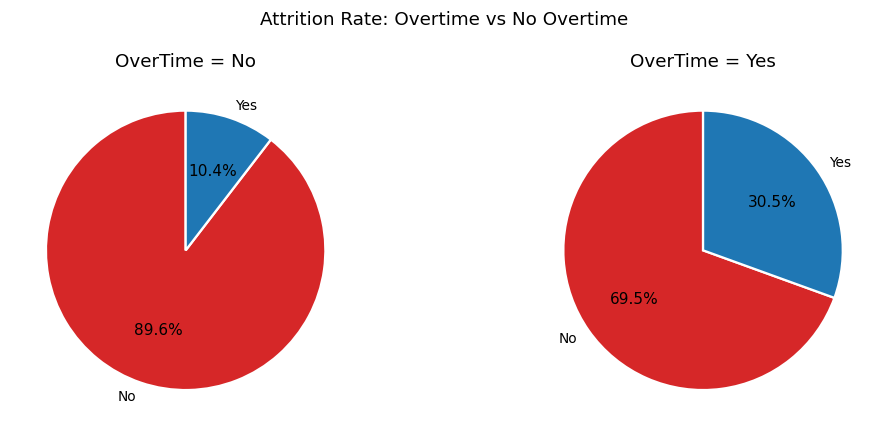

In [11]:
overtime_attr = (df.groupby('OverTime')['Attrition']
                   .value_counts(normalize=True)
                   .mul(100)
                   .unstack())

print("Attrition rate by overtime status:")
print(overtime_attr.round(2))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (ot_val, group) in zip(axes, df.groupby('OverTime')):
    counts = group['Attrition'].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90,
           colors=['#d62728', '#1f77b4'],
           wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
    ax.set_title(f'OverTime = {ot_val}')

plt.suptitle('Attrition Rate: Overtime vs No Overtime')
plt.tight_layout()
plt.savefig('05_overtime_attrition.png', bbox_inches='tight')
plt.show()

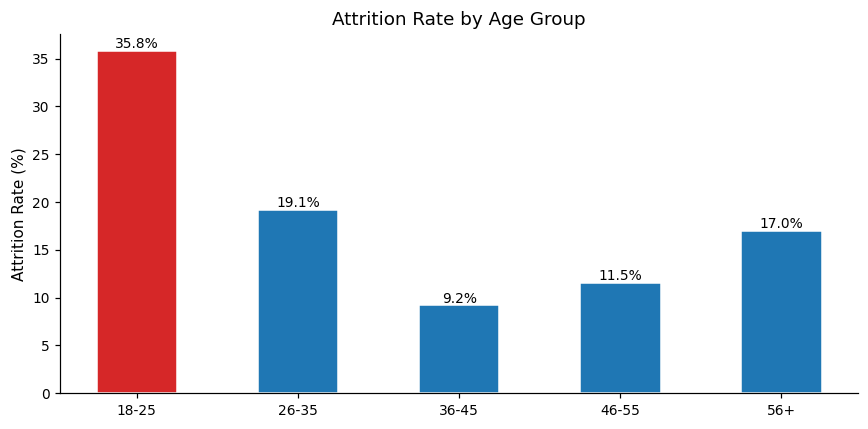

In [12]:
# Age group analysis
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[17, 25, 35, 45, 55, 65],
                        labels=['18-25', '26-35', '36-45', '46-55', '56+'])

age_attr = (df.groupby('AgeGroup', observed=True)['Attrition']
              .apply(lambda x: (x == 'Yes').mean() * 100))

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ['#d62728' if v == age_attr.max() else '#1f77b4' for v in age_attr]
bars = ax.bar(age_attr.index.astype(str), age_attr.values, color=bar_colors, edgecolor='white', width=0.5)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.set_title('Attrition Rate by Age Group')
ax.set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('06_attrition_by_age.png', bbox_inches='tight')
plt.show()

Monthly income by attrition status:
            count    mean     std     min     25%     50%     75%      max
Attrition                                                                 
No         1233.0  6833.0  4818.0  1051.0  3211.0  5204.0  8834.0  19999.0
Yes         237.0  4787.0  3640.0  1009.0  2373.0  3202.0  5916.0  19859.0


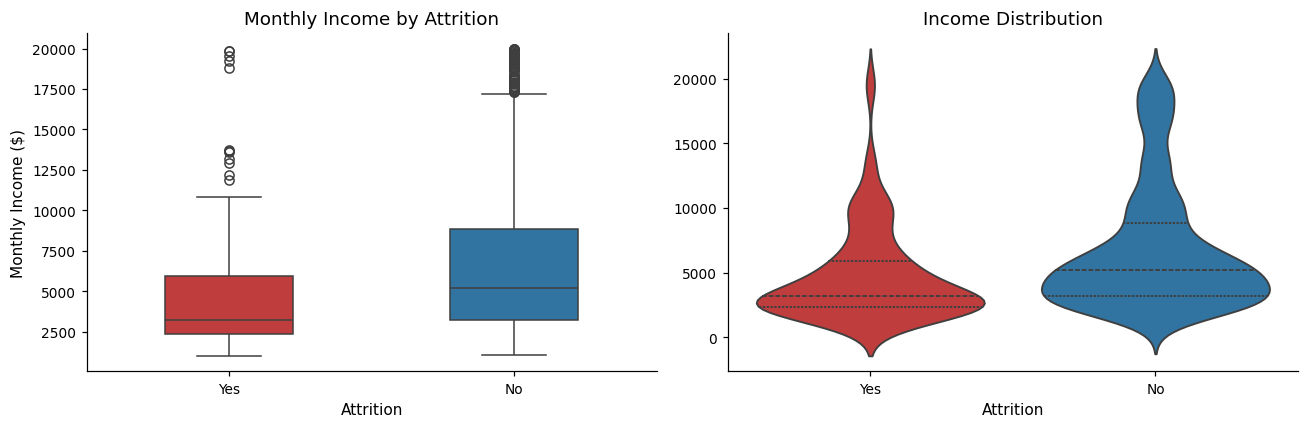

In [13]:
print("Monthly income by attrition status:")
print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
            palette={'Yes': '#d62728', 'No': '#1f77b4'}, ax=axes[0],
            width=0.45, legend=False)
axes[0].set_title('Monthly Income by Attrition')
axes[0].set_ylabel('Monthly Income ($)')

sns.violinplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition',
               palette={'Yes': '#d62728', 'No': '#1f77b4'}, ax=axes[1],
               inner='quartile', legend=False)
axes[1].set_title('Income Distribution')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('07_income_vs_attrition.png', bbox_inches='tight')
plt.show()

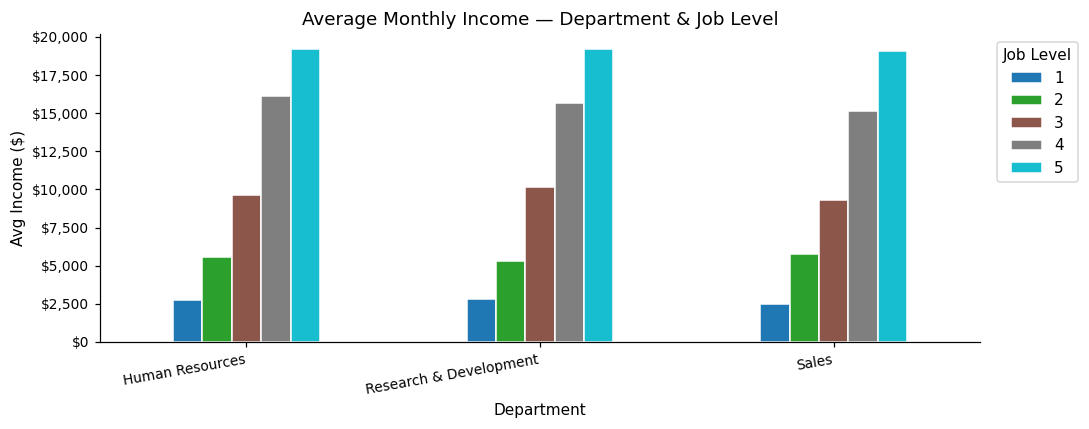

In [14]:
# Average income by department and job level
income_pivot = df.groupby(['Department', 'JobLevel'])['MonthlyIncome'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 4))
income_pivot.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Average Monthly Income — Department & Job Level')
ax.set_ylabel('Avg Income ($)')
ax.set_xticklabels(income_pivot.index, rotation=10, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(title='Job Level', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.savefig('08_income_dept_joblevel.png', bbox_inches='tight')
plt.show()

Avg salary hike by performance & attrition:
Attrition             No    Yes
PerformanceRating              
3                  14.04  13.81
4                  21.81  22.05


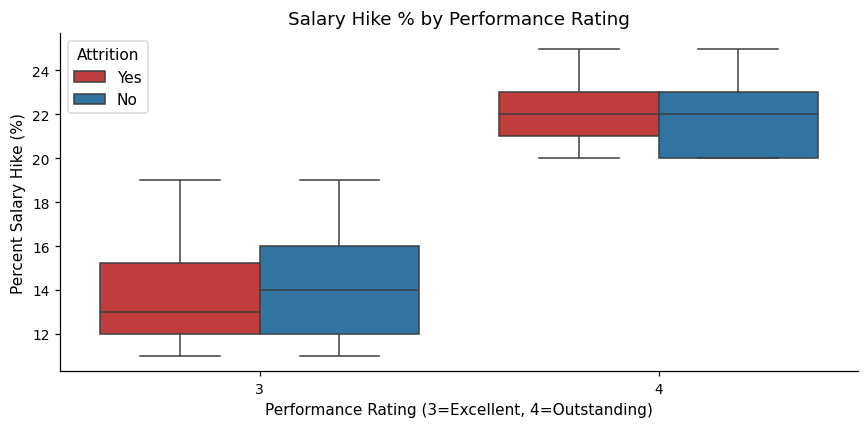

In [15]:
# Salary hike % by performance rating and attrition
print("Avg salary hike by performance & attrition:")
print(df.groupby(['PerformanceRating', 'Attrition'])['PercentSalaryHike'].mean().unstack().round(2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x='PerformanceRating', y='PercentSalaryHike',
            hue='Attrition', palette={'Yes': '#d62728', 'No': '#1f77b4'}, ax=ax)
ax.set_title('Salary Hike % by Performance Rating')
ax.set_xlabel('Performance Rating (3=Excellent, 4=Outstanding)')
ax.set_ylabel('Percent Salary Hike (%)')

plt.tight_layout()
plt.savefig('09_hike_vs_performance.png', bbox_inches='tight')
plt.show()

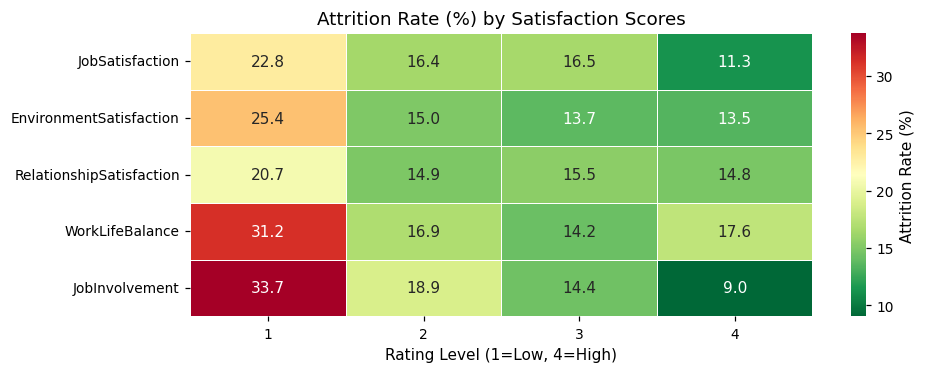

In [16]:
# Attrition rate across all satisfaction-related columns
sat_cols = ['JobSatisfaction', 'EnvironmentSatisfaction',
            'RelationshipSatisfaction', 'WorkLifeBalance', 'JobInvolvement']

sat_df = pd.DataFrame()
for col in sat_cols:
    temp = (df.groupby(col)['Attrition']
              .apply(lambda x: (x == 'Yes').mean() * 100)
              .rename(col))
    sat_df = pd.concat([sat_df, temp], axis=1)

fig, ax = plt.subplots(figsize=(9, 3.5))
sns.heatmap(sat_df.T, annot=True, fmt='.1f', cmap='RdYlGn_r',
            ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Attrition Rate (%)'})
ax.set_title('Attrition Rate (%) by Satisfaction Scores')
ax.set_xlabel('Rating Level (1=Low, 4=High)')

plt.tight_layout()
plt.savefig('10_satisfaction_heatmap.png', bbox_inches='tight')
plt.show()

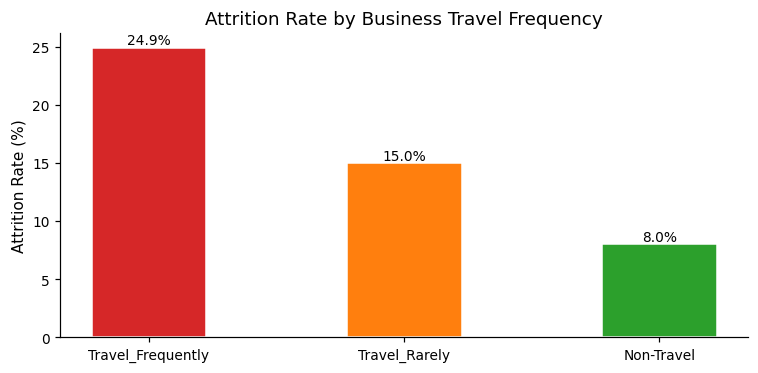

In [17]:
# Business travel frequency vs attrition
travel_attr = (df.groupby('BusinessTravel')['Attrition']
                 .apply(lambda x: (x == 'Yes').mean() * 100)
                 .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(travel_attr.index, travel_attr.values,
              color=['#d62728', '#ff7f0e', '#2ca02c'], edgecolor='white', width=0.45)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.set_title('Attrition Rate by Business Travel Frequency')
ax.set_ylabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('11_travel_attrition.png', bbox_inches='tight')
plt.show()

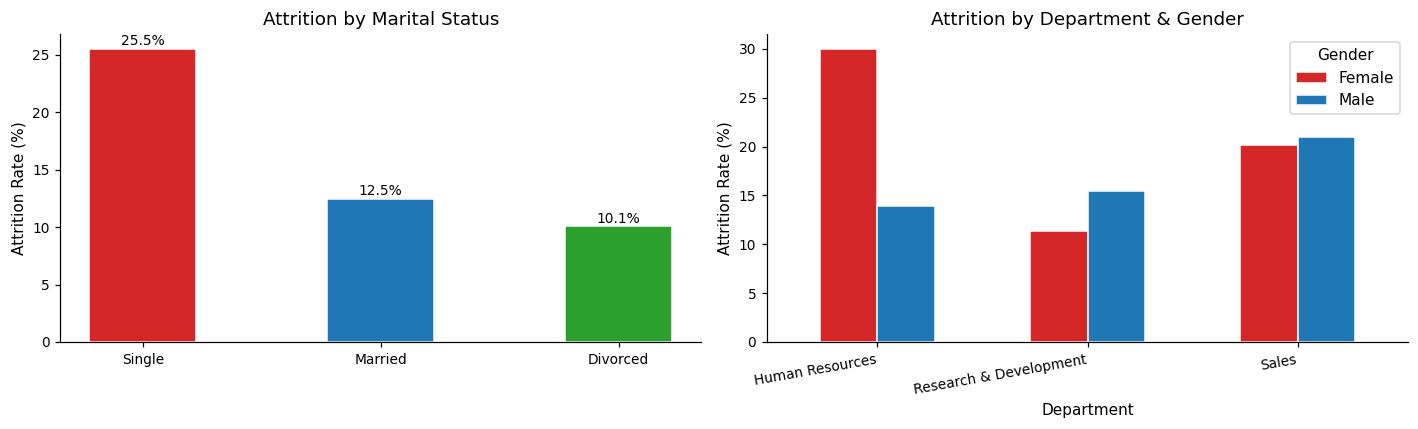

In [18]:
# Marital status and gender attrition patterns
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

marital_attr = (df.groupby('MaritalStatus')['Attrition']
                  .apply(lambda x: (x == 'Yes').mean() * 100)
                  .sort_values(ascending=False))
axes[0].bar(marital_attr.index, marital_attr.values,
            color=['#d62728', '#1f77b4', '#2ca02c'], edgecolor='white', width=0.45)
for i, v in enumerate(marital_attr.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_title('Attrition by Marital Status')
axes[0].set_ylabel('Attrition Rate (%)')

gender_dept = (df.groupby(['Department', 'Gender'])['Attrition']
                 .apply(lambda x: (x == 'Yes').mean() * 100)
                 .unstack())
gender_dept.plot(kind='bar', ax=axes[1], color=['#d62728', '#1f77b4'],
                 edgecolor='white', width=0.55)
axes[1].set_title('Attrition by Department & Gender')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xticklabels(gender_dept.index, rotation=10, ha='right')
axes[1].legend(title='Gender')

plt.tight_layout()
plt.savefig('12_demographic_attrition.png', bbox_inches='tight')
plt.show()

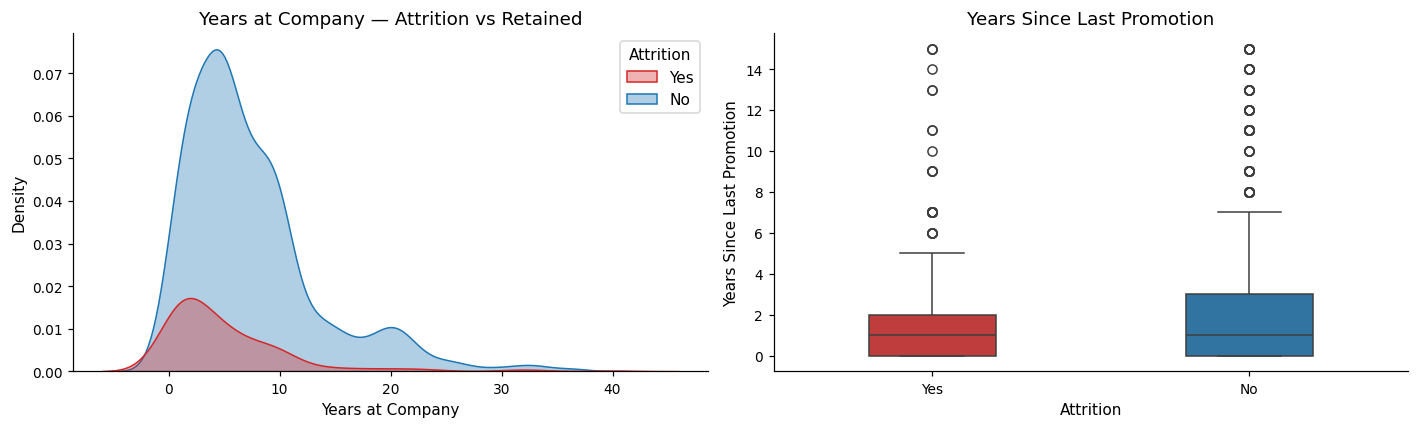

In [19]:
# Tenure and promotion gap analysis
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.kdeplot(data=df, x='YearsAtCompany', hue='Attrition',
            palette={'Yes': '#d62728', 'No': '#1f77b4'},
            ax=axes[0], fill=True, alpha=0.35)
axes[0].set_title('Years at Company — Attrition vs Retained')
axes[0].set_xlabel('Years at Company')

sns.boxplot(data=df, x='Attrition', y='YearsSinceLastPromotion', hue='Attrition',
            palette={'Yes': '#d62728', 'No': '#1f77b4'},
            ax=axes[1], width=0.4, legend=False)
axes[1].set_title('Years Since Last Promotion')
axes[1].set_ylabel('Years Since Last Promotion')

plt.tight_layout()
plt.savefig('13_tenure_promotion.png', bbox_inches='tight')
plt.show()

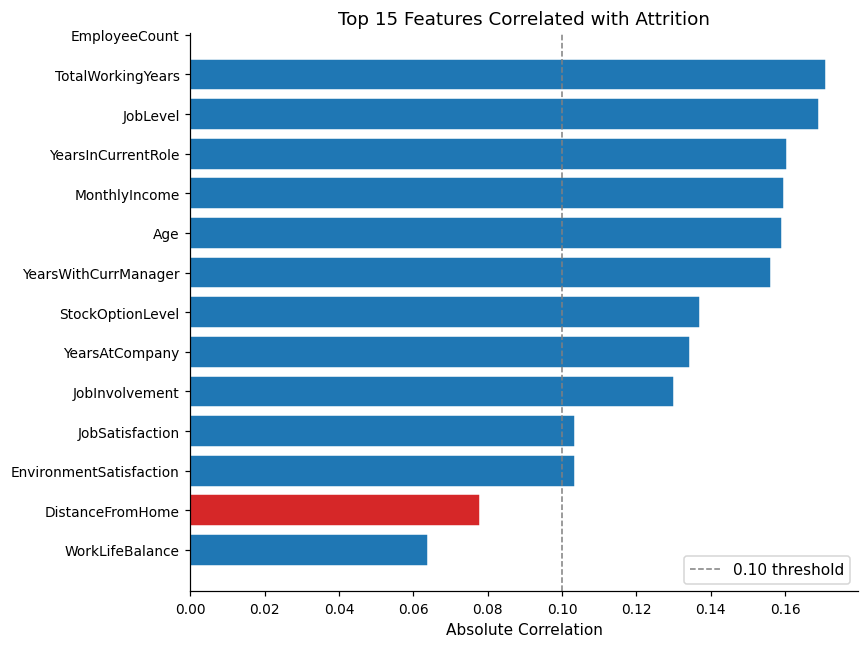

Top 10 features by correlation with attrition:
TotalWorkingYears       0.1711
JobLevel                0.1691
YearsInCurrentRole      0.1605
MonthlyIncome           0.1598
Age                     0.1592
YearsWithCurrManager    0.1562
StockOptionLevel        0.1371
YearsAtCompany          0.1344
JobInvolvement          0.1300
JobSatisfaction         0.1035
Name: Attrition_num, dtype: float64


In [20]:
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
corr_with_attrition = (df_corr[numeric_cols].corr()['Attrition_num']
                         .drop('Attrition_num')
                         .abs()
                         .sort_values(ascending=True)
                         .tail(15))

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = ['#d62728' if df_corr[numeric_cols].corr()['Attrition_num'][f] > 0
              else '#1f77b4' for f in corr_with_attrition.index]
ax.barh(corr_with_attrition.index, corr_with_attrition.values,
        color=bar_colors, edgecolor='white')
ax.axvline(x=0.1, color='gray', linestyle='--', linewidth=1, label='0.10 threshold')
ax.set_title('Top 15 Features Correlated with Attrition')
ax.set_xlabel('Absolute Correlation')
ax.legend()

plt.tight_layout()
plt.savefig('14_correlation_with_attrition.png', bbox_inches='tight')
plt.show()

print("Top 10 features by correlation with attrition:")
print(corr_with_attrition.sort_values(ascending=False).head(10).round(4))

In [22]:
# Summary of key metrics
summary = {
    'Metric': [
        'Total Employees',
        'Overall Attrition Rate',
        'Avg Monthly Income (Stayed)',
        'Avg Monthly Income (Left)',
        'Attrition Rate — Overtime = Yes',
        'Attrition Rate — Overtime = No',
        'Sales Dept Attrition Rate',
        'R&D Dept Attrition Rate',
        'Highest Attrition Age Group',
    ],
    'Value': [
        len(df),
        f"{(df['Attrition'] == 'Yes').mean() * 100:.1f}%",
        f"${df[df['Attrition'] == 'No']['MonthlyIncome'].mean():,.0f}",
        f"${df[df['Attrition'] == 'Yes']['MonthlyIncome'].mean():,.0f}",
        f"{df[df['OverTime'] == 'Yes']['Attrition'].eq('Yes').mean() * 100:.1f}%",
        f"{df[df['OverTime'] == 'No']['Attrition'].eq('Yes').mean() * 100:.1f}%",
        f"{df[df['Department'] == 'Sales']['Attrition'].eq('Yes').mean() * 100:.1f}%",
        f"{df[df['Department'] == 'Research & Development']['Attrition'].eq('Yes').mean() * 100:.1f}%",
        '18-25',
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

                         Metric  Value
                Total Employees   1470
         Overall Attrition Rate  16.1%
    Avg Monthly Income (Stayed) $6,833
      Avg Monthly Income (Left) $4,787
Attrition Rate — Overtime = Yes  30.5%
 Attrition Rate — Overtime = No  10.4%
      Sales Dept Attrition Rate  20.6%
        R&D Dept Attrition Rate  13.8%
    Highest Attrition Age Group  18-25
